# Region-Based Necrotic Segmentation

Instead of thresholding individual voxels, find **spatially coherent regions** of low PE within each tumor.

Approach: use K-means clustering on PE values with spatial coordinates, then identify the cluster with lowest mean PE as necrotic. This finds "blobs" of similar tissue rather than evaluating each voxel independently.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

base = '/Users/samantha/Desktop/tul/china data'

patients = [
    ('P11 V1', 'p11/new_v1/paramap'),
    ('P11 V2', 'p11/new_v2/paramap'),
    ('P27 V1', 'p27/new_v1/paramap'),
    ('P27 V2', 'p27/new_v2/paramap'),
    ('P34 V1', 'p34/new_v1/paramap'),
    ('P34 V2', 'p34/new_v2/paramap'),
    ('P39 V1', 'p39/new_v1/paramap'),
    ('P39 V2', 'p39/new_v2/paramap'),
]

## 1. Load data

In [2]:
data = {}

for label_name, path in patients:
    pe = np.load(f'{base}/{path}/PE_full_TIC_numerical.npy')
    roi = np.load(f'{base}/{path}/segmentation.npy')
    data[label_name] = {'pe': pe, 'roi': roi}
    
    valid = pe[(roi > 0) & np.isfinite(pe) & (pe > 0)]
    print(f'{label_name}: {np.sum(roi > 0):,} voxels, PE [{np.min(valid):.3f}, {np.max(valid):.3f}]')

P11 V1: 605,265 voxels, PE [0.076, 0.987]
P11 V2: 392,310 voxels, PE [0.282, 1.019]
P27 V1: 360,689 voxels, PE [0.426, 1.123]
P27 V2: 206,152 voxels, PE [0.504, 1.144]
P34 V1: 301,141 voxels, PE [0.367, 1.163]
P34 V2: 213,727 voxels, PE [0.129, 1.063]
P39 V1: 248,657 voxels, PE [0.275, 1.053]
P39 V2: 229,718 voxels, PE [0.187, 1.110]


## 2. K-means clustering

In [ ]:
# ===== ADJUST THESE =====
N_CLUSTERS = 2
SPATIAL_WEIGHT = 0.3  # How much spatial proximity matters vs PE value (try 0.1 to 0.5)
# ========================

results = {}

for label_name, path in patients:
    pe = data[label_name]['pe']
    roi = data[label_name]['roi']
    
    # Get voxel coordinates and PE values within ROI
    mask = (roi > 0) & np.isfinite(pe) & (pe > 0)
    coords = np.array(np.where(mask)).T  # shape: (N, 3) — x, y, z
    pe_vals = pe[mask]
    
    # Normalize PE to [0, 1]
    pe_norm = (pe_vals - pe_vals.min()) / (pe_vals.max() - pe_vals.min())
    
    # Normalize spatial coords to [0, 1]
    coords_norm = coords.astype(float)
    for dim in range(3):
        cmin, cmax = coords_norm[:, dim].min(), coords_norm[:, dim].max()
        if cmax > cmin:
            coords_norm[:, dim] = (coords_norm[:, dim] - cmin) / (cmax - cmin)
        else:
            coords_norm[:, dim] = 0
    
    # Build feature matrix: [PE, x, y, z] with spatial weighting
    features = np.column_stack([
        pe_norm,
        coords_norm * SPATIAL_WEIGHT
    ])
    
    # K-means
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)
    
    # Identify which cluster is "necrotic" (lowest mean PE)
    cluster_means = [pe_vals[labels == c].mean() for c in range(N_CLUSTERS)]
    necrotic_cluster = np.argmin(cluster_means)
    
    # Build 3D mask
    necrotic_mask = np.zeros_like(roi, dtype=bool)
    viable_mask = np.zeros_like(roi, dtype=bool)
    
    for idx, (x, y, z) in enumerate(coords):
        if labels[idx] == necrotic_cluster:
            necrotic_mask[x, y, z] = True
        else:
            viable_mask[x, y, z] = True
    
    n_total = np.sum(mask)
    n_necrotic = np.sum(necrotic_mask)
    pct = n_necrotic / n_total * 100
    
    results[label_name] = {
        'necrotic_mask': necrotic_mask,
        'viable_mask': viable_mask,
        'cluster_means': cluster_means,
        'necrotic_cluster': necrotic_cluster,
        'features': features,
        'labels': labels,
        'centers': kmeans.cluster_centers_,
    }
    
    print(f'{label_name}: cluster means = {[f"{m:.3f}" for m in cluster_means]}, '
          f'necrotic cluster = {necrotic_cluster}, '
          f'{n_necrotic:,}/{n_total:,} necrotic ({pct:.1f}%)')

## 2b. Cluster scatterplot — PE vs spatial position

Each voxel plotted in 2D feature space: normalized PE (x-axis) vs dominant spatial dimension (y-axis). Colored by cluster assignment. Red X = cluster centers.

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, (label_name, path) in enumerate(patients):
    ax = axes[i // 2, i % 2]
    
    features = results[label_name]['features']
    labels = results[label_name]['labels']
    centers = results[label_name]['centers']
    necrotic_cluster = results[label_name]['necrotic_cluster']
    viable_cluster = 1 - necrotic_cluster
    
    # Features: col 0 = norm PE, cols 1-3 = spatial*weight
    # Pick the spatial dim with most variance for y-axis
    spatial_vars = [features[:, d].var() for d in [1, 2, 3]]
    best_spatial = np.argmax(spatial_vars) + 1  # +1 because col 0 is PE
    dim_names = ['x', 'y', 'z']
    
    # Subsample for plotting
    max_pts = 3000
    rng = np.random.RandomState(42)
    
    for c, color, lbl in [(viable_cluster, '#3b82f6', 'Viable'), 
                           (necrotic_cluster, '#f97316', 'Necrotic')]:
        c_mask = labels == c
        c_feat = features[c_mask]
        if len(c_feat) > max_pts:
            idx = rng.choice(len(c_feat), max_pts, replace=False)
            c_feat = c_feat[idx]
        ax.scatter(c_feat[:, 0], c_feat[:, best_spatial], 
                   c=color, alpha=0.2, s=6, edgecolors='none', label=f'{lbl} (n={np.sum(c_mask):,})')
    
    # Plot cluster centers
    for c in range(N_CLUSTERS):
        ax.scatter(centers[c, 0], centers[c, best_spatial], 
                   c='red', marker='X', s=200, edgecolors='black', linewidths=1.5, zorder=10)
    
    ax.set_xlabel('Normalized PE', fontsize=10)
    ax.set_ylabel(f'Spatial {dim_names[best_spatial-1]} (×{SPATIAL_WEIGHT})', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title(f'{label_name}', fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle(f'K-means Feature Space (K={N_CLUSTERS}, SW={SPATIAL_WEIGHT}) — PE vs Dominant Spatial Dim', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 3. PE heatmap vs clustering — all patients (largest slice)

Side-by-side: PE heatmap (left) and PE of viable-only voxels (right) for each patient.

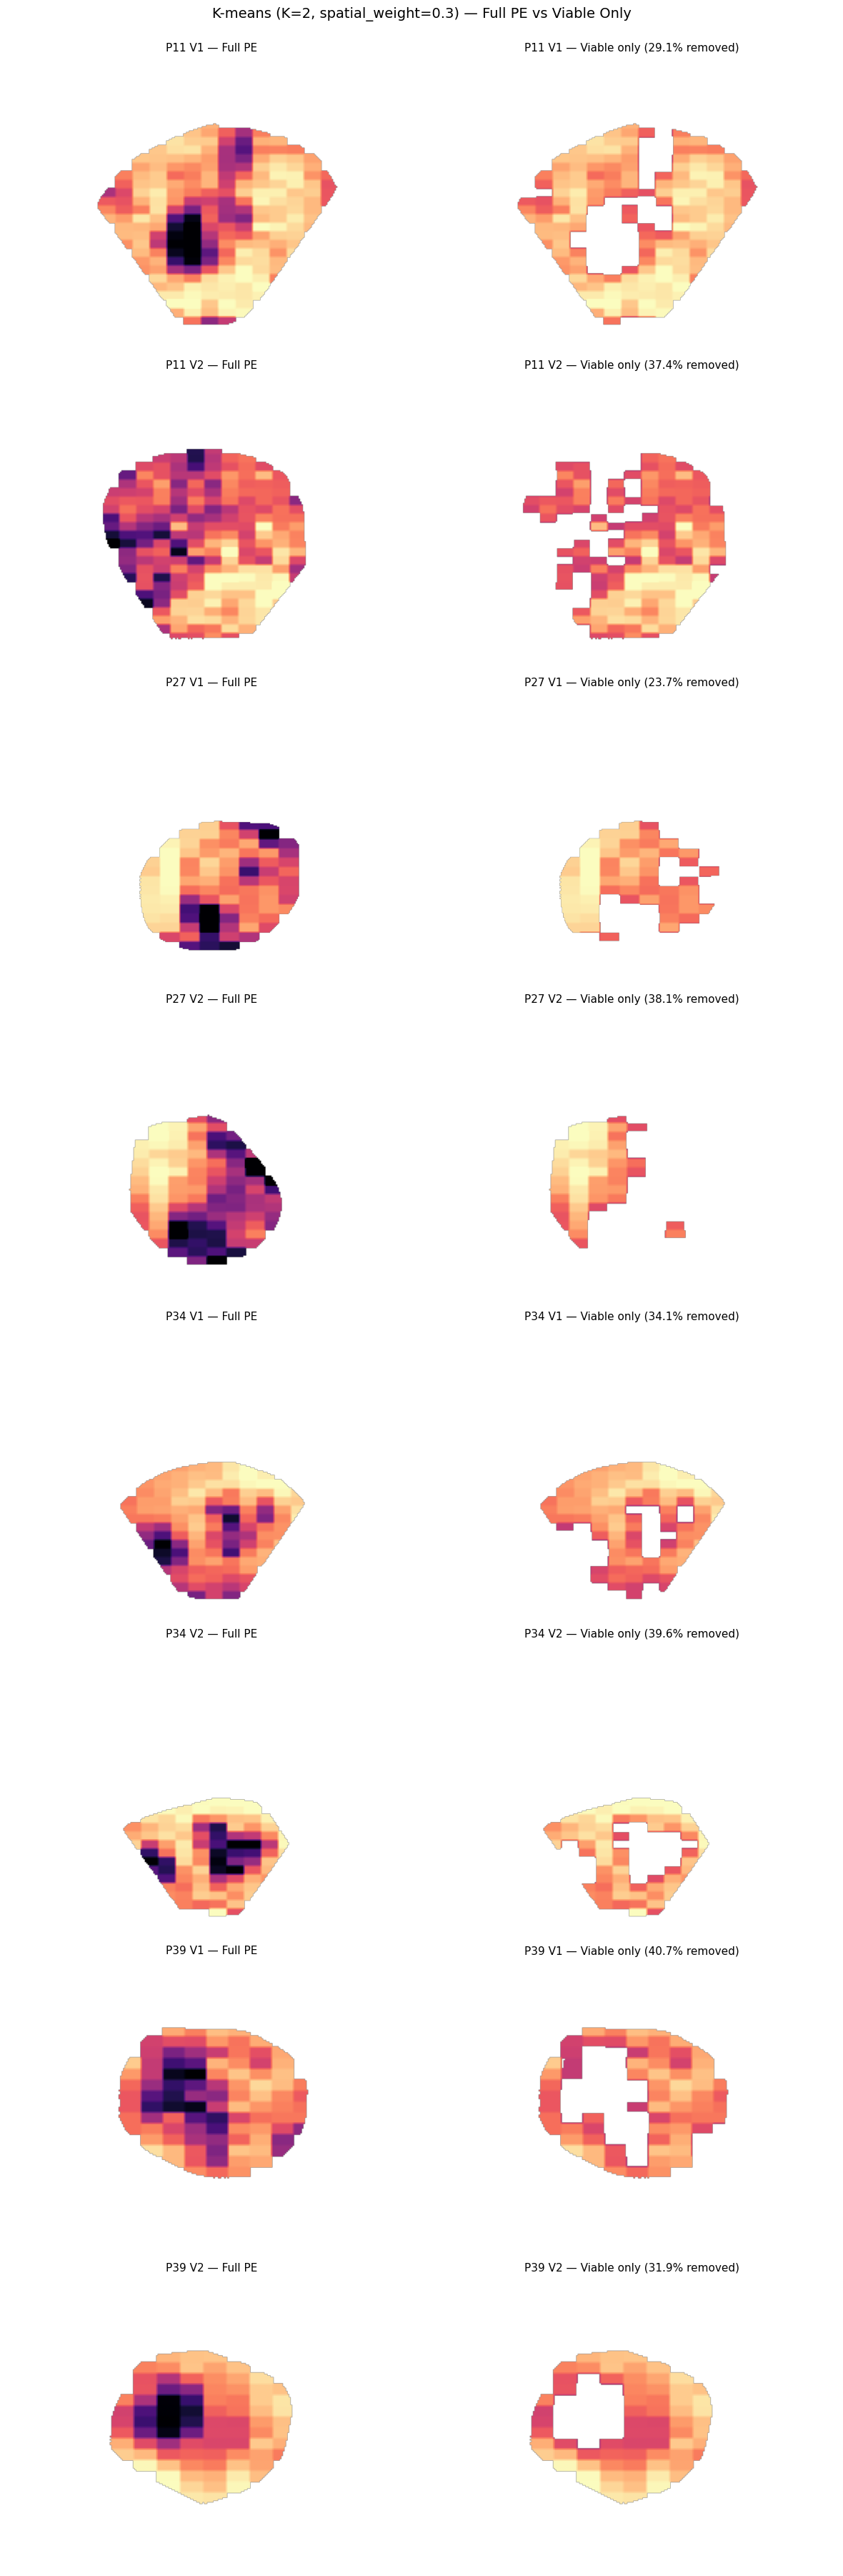

In [4]:
fig, axes = plt.subplots(8, 2, figsize=(12, 36))

for i, (label_name, path) in enumerate(patients):
    pe = data[label_name]['pe']
    roi = data[label_name]['roi']
    necrotic_mask = results[label_name]['necrotic_mask']
    viable_mask = results[label_name]['viable_mask']
    
    slice_idx = np.argmax([np.sum(roi[:, :, z] > 0) for z in range(roi.shape[2])])
    
    pe_valid = pe[(roi > 0) & np.isfinite(pe) & (pe > 0)]
    pe_vmin = np.percentile(pe_valid, 2)
    pe_vmax = np.percentile(pe_valid, 98)
    
    n_total = np.sum((roi > 0) & np.isfinite(pe) & (pe > 0))
    n_necrotic = np.sum(necrotic_mask)
    pct = n_necrotic / n_total * 100
    
    # Left: full PE heatmap
    ax1 = axes[i, 0]
    pe_slice = np.where(roi[:, :, slice_idx] > 0, pe[:, :, slice_idx], np.nan)
    im1 = ax1.imshow(np.rot90(pe_slice), cmap='magma', vmin=pe_vmin, vmax=pe_vmax)
    ax1.set_title(f'{label_name} — Full PE', fontsize=11)
    ax1.axis('off')
    
    # Right: PE of viable voxels only (necrotic removed)
    ax2 = axes[i, 1]
    pe_viable = np.where(viable_mask[:, :, slice_idx], pe[:, :, slice_idx], np.nan)
    ax2.imshow(np.rot90(pe_viable), cmap='magma', vmin=pe_vmin, vmax=pe_vmax)
    ax2.set_title(f'{label_name} — Viable only ({pct:.1f}% removed)', fontsize=11)
    ax2.axis('off')

plt.suptitle(f'K-means (K={N_CLUSTERS}, spatial_weight={SPATIAL_WEIGHT}) — Full PE vs Viable Only', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 4. P34 focus — PE heatmap vs viable-only (largest slice)

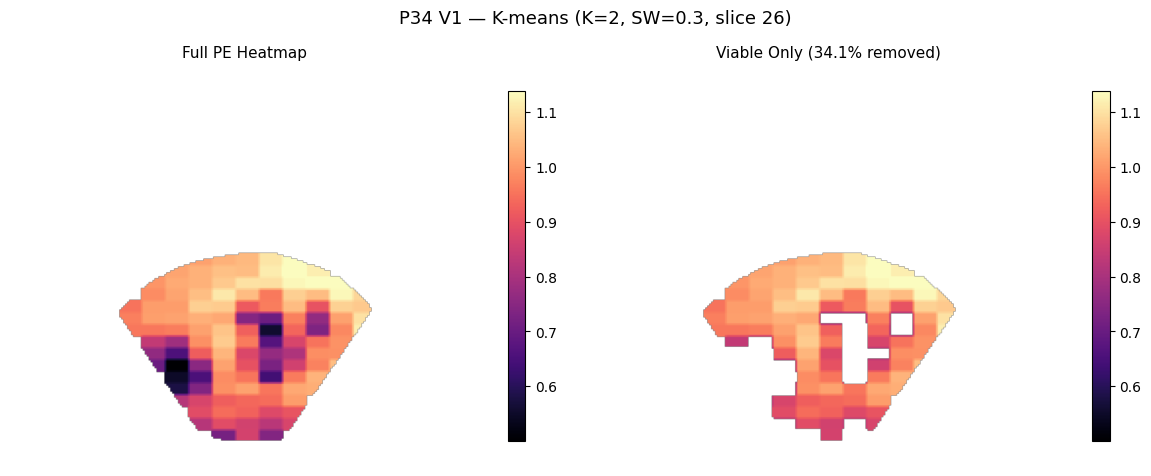

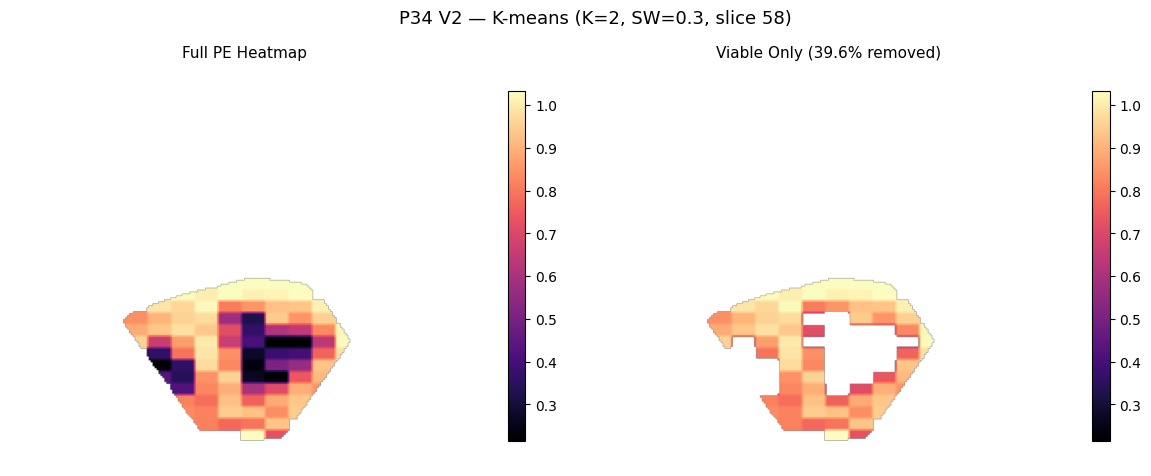

In [5]:
for label_name in ['P34 V1', 'P34 V2']:
    pe = data[label_name]['pe']
    roi = data[label_name]['roi']
    necrotic_mask = results[label_name]['necrotic_mask']
    viable_mask = results[label_name]['viable_mask']
    
    slice_idx = np.argmax([np.sum(roi[:, :, z] > 0) for z in range(roi.shape[2])])
    
    pe_valid = pe[(roi > 0) & np.isfinite(pe) & (pe > 0)]
    pe_vmin = np.percentile(pe_valid, 2)
    pe_vmax = np.percentile(pe_valid, 98)
    
    n_total = np.sum((roi > 0) & np.isfinite(pe) & (pe > 0))
    n_necrotic = np.sum(necrotic_mask)
    pct = n_necrotic / n_total * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # PE heatmap (full)
    pe_slice = np.where(roi[:, :, slice_idx] > 0, pe[:, :, slice_idx], np.nan)
    im1 = ax1.imshow(np.rot90(pe_slice), cmap='magma', vmin=pe_vmin, vmax=pe_vmax)
    ax1.set_title('Full PE Heatmap', fontsize=11)
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1, shrink=0.8)
    
    # PE of viable only
    pe_viable = np.where(viable_mask[:, :, slice_idx], pe[:, :, slice_idx], np.nan)
    im2 = ax2.imshow(np.rot90(pe_viable), cmap='magma', vmin=pe_vmin, vmax=pe_vmax)
    ax2.set_title(f'Viable Only ({pct:.1f}% removed)', fontsize=11)
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2, shrink=0.8)
    
    fig.suptitle(f'{label_name} — K-means (K={N_CLUSTERS}, SW={SPATIAL_WEIGHT}, slice {slice_idx})', fontsize=13)
    plt.tight_layout()
    plt.show()

## 5. Summary table

In [7]:
print(f"{'Patient':<10} {'Total':>10} {'Necrotic':>10} {'% Necrotic':>12} {'Viable Mean PE':>16} {'Necrotic Mean PE':>18}")
print('-' * 80)

for label_name, path in patients:
    pe = data[label_name]['pe']
    roi = data[label_name]['roi']
    necrotic_mask = results[label_name]['necrotic_mask']
    viable_mask = results[label_name]['viable_mask']
    
    n_total = np.sum(necrotic_mask) + np.sum(viable_mask)
    n_necro = np.sum(necrotic_mask)
    pct = n_necro / n_total * 100
    
    viable_pe = pe[viable_mask & np.isfinite(pe)].mean()
    necro_pe = pe[necrotic_mask & np.isfinite(pe)].mean() if n_necro > 0 else 0
    
    print(f'{label_name:<10} {n_total:>10,} {n_necro:>10,} {pct:>11.1f}% {viable_pe:>16.4f} {necro_pe:>18.4f}')

Patient         Total   Necrotic   % Necrotic   Viable Mean PE   Necrotic Mean PE
--------------------------------------------------------------------------------
P11 V1        597,334    173,970        29.1%           0.8099             0.4731
P11 V2        386,466    144,384        37.4%           0.8093             0.5746
P27 V1        351,898     83,544        23.7%           1.0198             0.7629
P27 V2        202,393     77,078        38.1%           1.0646             0.8858
P34 V1        296,549    101,117        34.1%           0.9726             0.6796
P34 V2        209,335     82,806        39.6%           0.8772             0.4982
P39 V1        243,576     99,074        40.7%           0.8773             0.5604
P39 V2        223,727     71,263        31.9%           0.9322             0.4763


## 7. Export viable mask as .nii.gz — P34 V1 & V2

Saves a binary mask (1=viable, 0=necrotic/background) using the affine and spacing from the original CEUS scan — same format as `necrotic_area_subtraction` output.

In [ ]:
import nibabel as nib
import os

# Scan paths for loading affine/spacing
scan_paths = {
    'P34 V1': '/Users/samantha/Desktop/tul/china data/p34/new_v1/CEUS-26152-1.nii.gz',
    'P34 V2': '/Users/samantha/Desktop/tul/china data/p34/new_v2/CEUS-26285-2.nii',
}

export_scans = [('P34 V1', 'p34/new_v1'), ('P34 V2', 'p34/new_v2')]

for label_name, path in export_scans:
    viable_mask = results[label_name]['viable_mask']
    necrotic_mask = results[label_name]['necrotic_mask']
    
    # Load affine and zooms from the original CEUS scan
    scan_nii = nib.load(scan_paths[label_name])
    affine = scan_nii.affine
    zooms = scan_nii.header.get_zooms()[:3]
    
    # Binary mask: 1 = viable, 0 = necrotic/background
    final_mask = viable_mask.astype(np.uint8)
    
    # Save as nii.gz with correct affine and zooms
    out_dir = f'{base}/{path}'
    out_img = nib.Nifti1Image(final_mask, affine)
    out_img.header.set_zooms(zooms)
    
    nii_path = os.path.join(out_dir, 'voi_kmeans_viable.nii.gz')
    nib.save(out_img, nii_path)
    
    # Also save as .npy for notebook pipeline
    npy_path = os.path.join(out_dir, 'voi_kmeans_viable.npy')
    np.save(npy_path, final_mask)
    
    n_total = np.sum(viable_mask) + np.sum(necrotic_mask)
    n_viable = np.sum(viable_mask)
    n_necro = np.sum(necrotic_mask)
    
    print(f'{label_name}:')
    print(f'  Scan affine from: {os.path.basename(scan_paths[label_name])}')
    print(f'  Zooms: {zooms}')
    print(f'  Saved .nii.gz → {nii_path}')
    print(f'  Saved .npy    → {npy_path}')
    print(f'  Shape: {final_mask.shape}')
    print(f'  Viable: {n_viable:,} | Necrotic removed: {n_necro:,} ({n_necro/n_total*100:.1f}%)')
    print()